In [269]:
%load_ext autoreload
%autoreload 2

import pickle
import ujson
import json
import sys
import os
from collections import Counter, defaultdict


import pandas as pd
import numpy as np
import torch
import random
import faiss
import gzip

from tqdm import tqdm
from typing import Optional

from bioel.utils.umls_utils import UmlsMappings
from bioel.utils.bigbio_utils import CUIS_TO_REMAP, CUIS_TO_EXCLUDE, DATASET_NAMES, VALIDATION_DOCUMENT_IDS
from bioel.utils.bigbio_utils import load_bigbio_dataset, add_deabbreviations, load_dataset_df, dataset_to_documents, dataset_to_df, load_dataset_df, resolve_abbreviation, dataset_unique_tax_ids
from bioel.dataset import Dataset
from bioel.utils.solve_abbreviation.solve_abbreviations import create_abbrev
from bioel.ontology import BiomedicalOntology
from bioel.models.arboel.biencoder.data.data_utils import process_ontology
from bioel.evaluate import Evaluate

from torch.utils.data import DataLoader

from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportions_ztest

from peft import PeftModel
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams
from ids import open_ai_api_key
import matplotlib.pyplot as plt
from utils_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [270]:
import openai
openai.api_key = open_ai_api_key
import re
import logging

# Set up logging configuration
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logging.getLogger("httpx").setLevel(logging.WARNING)
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
device_0 = torch.device("cuda:3")
device_1 = torch.device("cuda:0")
device_2 = torch.device("cuda:1")
device_3 = torch.device("cuda:2")
sampling_params = SamplingParams(temperature=0, top_p=0.9, max_tokens=1000, stop=["<|eot_id|>"])

In [271]:
# Check how many GPUs are visible
print(f"Visible GPUs: {torch.cuda.device_count()}")

# Check if you can access both GPUs
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

seed = 40
np.random.seed(seed)
random.seed(seed)

Visible GPUs: 1
GPU 0: NVIDIA A40


In [526]:
##### ----------------- Load medic ----------------- #####

# dataset_name = 'ncbi_disease'
# medic_dict = {"name" : "medic",
#             "filepath" : "/mitchell/entity-linking/kbs/medic.tsv"}

# ontology2 = BiomedicalOntology.load_medic(**medic_dict)

# ##### ----------------- Load entrez ----------------- #####

# # dataset_name = "gnormplus" 
# dataset_name = "nlm_gene"

# entrez_dict = {"name" : "entrez",
#              "filepath" : "/mitchell/entity-linking/el-robustness-comparison/data/gene_info.tsv",
#              "dataset" : f"{dataset_name}",}
# ontology2 = BiomedicalOntology.load_entrez(**entrez_dict)

# ##### ----------------- Load MESH ----------------- #####

# dataset_name = "nlmchem"
# mesh_dict = {"name" : "mesh",
#              "filepath" : "/mitchell/entity-linking/2017AA/META/"}
# ontology2 = BiomedicalOntology.load_mesh(**mesh_dict)

##### ----------------- Load UMLS (st21pv subset) ----------------- #####

dataset_name = "medmentions_st21pv"
umls_dict_st21pv = {
    "name": "umls",
    "filepath": "/mitchell/entity-linking/2017AA/META/",
    "path_st21pv_cui": "/home2/cye73/data_test2/arboel/medmentions_st21pv/umls_cuis_st21pv.json",
}
ontology2 = BiomedicalOntology.load_umls(**umls_dict_st21pv)

# # ##### ----------------- Load UMLS (full) ----------------- #####

# dataset_name = "medmentions_full"
# umls_dict = {
#     "name": "umls",
#     "filepath": "/mitchell/entity-linking/2017AA/META/",
# }
# ontology2 = BiomedicalOntology.load_umls(**umls_dict)


[2024-10-15 18:59:16] [ontology.py] [INFO] Reading UMLS from /mitchell/entity-linking/2017AA/META/


Loading cached UMLS data from /mitchell/entity-linking/2017AA/META/.cached_df.feather


/home2/cye73/biomedical-entity-linking/bioel/bioel/utils/umls_utils.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["identifier"] = df["cui"]
/home2/cye73/biomedical-entity-linking/bioel/bioel/ontology.py:378: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: list(set(x[1]) - set([x[0]])), axis=1


Number of entities : 2369483


Loading UMLS Ontology: 2369483it [04:51, 8122.93it/s] 


In [562]:
EL_model = "sapbert"
# EL_model = "arboel"

In [563]:
# # Save the ontology
# with gzip.open('/home/cye73/llm_disambiguator/experiments/ontology/medic_ontology.pkl.gz', 'wb') as f:
#     pickle.dump(ontology2, f)

# # Load the ontology
# with gzip.open('/home/cye73/llm_disambiguator/experiments/ontology/medic_ontology.pkl.gz', 'rb') as f:
#     ontology2 = pickle.load(f)

In [564]:
# # Specify the path to the file
# file_path = "/home/cye73/llm_disambiguator/experiments/ontology/medic_ontology.pkl.gz"
# # Get the size of the file
# file_size = os.path.getsize(file_path)
# # Convert the size to a human-readable format (KB, MB, etc.)
# print(f"File size: {file_size} bytes")

In [565]:
path_to_abbrev = "/home2/cye73/data_test2/abbreviations.json"
dataset = load_bigbio_dataset(dataset_name)
dataset = add_deabbreviations(dataset, path_to_abbrev)

In [566]:
dataset_df = dataset_to_df(dataset)
test_df = dataset_df[dataset_df['split'] == 'test']
train_df = dataset_df[dataset_df['split'] == 'train']
test_df

,document_id,offsets,text,type,db_ids,split,deabbreviated_text,mention_id
82,25847295,"[[34, 43]]",apoptosis,[T038],[UMLS:C0162638],test,apoptosis,25847295.1
87,25847295,"[[55, 65]]",PC12 cells,[T017],[UMLS:C0085262],test,PC12 cells,25847295.2
73,25847295,"[[137, 144]]",present,[T033],[UMLS:C0150312],test,present,25847295.3
78,25847295,"[[206, 219]]",toxic effects,[T037],[UMLS:C0600688],test,toxic effects,25847295.4
79,25847295,"[[259, 268]]",Apoptosis,[T038],[UMLS:C0162638],test,Apoptosis,25847295.5
...,...,...,...,...,...,...,...,...
203011,28550165,"[[1665, 1695]]",microtubule-associated protein,[T103],[UMLS:C0026045],test,microtubule-associated protein,28550165.90
203012,28550165,"[[1725, 1743]]",metabolic function,[T038],[UMLS:C0597299],test,metabolic function,28550165.91
203014,28550165,"[[1813, 1825]]",microtubules,[T017],[UMLS:C0026046],test,microtubules,28550165.92
203015,28550165,"[[1843, 1855]]",cytoskeleton,[T017],[UMLS:C0010853],test,cytoskeleton,28550165.93


In [567]:
docs = dataset_to_documents(dataset)
# docs

In [568]:
add_full_context(df = test_df, docs=docs)
add_full_context(df = train_df, docs=docs)
# test_df

/home2/cye73/llm_disambiguator/src/utils_functions.py:378: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["contextualized_mention"] = contextualized_mentions
/home2/cye73/llm_disambiguator/src/utils_functions.py:378: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["contextualized_mention"] = contextualized_mentions


In [569]:
_, TestMap_mention2context = add_context(df = test_df, docs = docs)
corpus, TrainMap_mention2context = add_context(df = train_df, docs = docs)
_, _ = add_context(df = dataset_df, docs = docs)
# dataset_df

/home2/cye73/llm_disambiguator/src/utils_functions.py:425: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["limited_contextualized_mention"] = limited_contextualized_mentions
/home2/cye73/llm_disambiguator/src/utils_functions.py:425: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["limited_contextualized_mention"] = limited_contextualized_mentions


In [570]:
# # # Load a pre-trained SentenceBERT model
# # model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# # # Generate embeddings for the corpus
# # corpus_embeddings = model.encode(corpus, convert_to_tensor=True)

# from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('princeton-nlp/sup-simcse-bert-base-uncased')
# # model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# model.to(device_0)
# # Generate embeddings for the corpus
# corpus_embeddings = model.encode(corpus, convert_to_tensor=True)

# corpus_embeddings = corpus_embeddings.cpu().detach().numpy()

In [571]:
# embedding_dimension = corpus_embeddings.shape[1]

# # Create the HNSW index with the correct arguments
# M = 32  # Number of neighbors in the HNSW graph
# index = faiss.IndexHNSWFlat(embedding_dimension, M)

# # Normalize the corpus embeddings if using cosine similarity
# faiss.normalize_L2(corpus_embeddings)

# # Add the embeddings to the index
# index.add(corpus_embeddings)

# # Print the number of sentences added to the index
# print(f"Number of sentences in the index: {index.ntotal}")

In [572]:
TrainMap_context2mention = {v: k for k, v in TrainMap_mention2context.items()}
# TrainMap_context2mention

In [573]:
# with open(f"/home/cye73/data_test2/sapbert/gnormplus/finetuned_models_nice/sapbert_gnormplus_2.json", "r") as f:
#     sapbert_res = ujson.load(f)
# sapbert_res

In [574]:
# processed_res = process_candidates_sapbert(sapbert_res)
# processed_res[0]
# sapbert_res[0]

In [575]:
# with open(f"/home2/cye73/results2/sapbert/sapbert_gnormplus_real2.json", "w") as f:
#     ujson.dump(processed_res, f, indent=4)

# Load arboel results

In [576]:
dataset_names = [f"{dataset_name}"]

model_names = [f"{EL_model}"]

eval_strategies = ['basic']

# Add paths based on the value of EL_model
path_to_result = {f"{dataset_name}": {}}

if EL_model == "arboel":
    path_to_result[dataset_name][EL_model] = f"candidates/{dataset_name}/{EL_model}_{dataset_name}.json"
elif EL_model == "sapbert":
    if dataset_name == ("nlm_gene" or "gnormplus"):
        print("here") 
        path_to_result[dataset_name][EL_model] = f"candidates/{dataset_name}/{EL_model}_{dataset_name}_real2.json"
    else : 
        path_to_result[dataset_name][EL_model] = f"candidates/{dataset_name}/{EL_model}_{dataset_name}_real.json"
evaluator = Evaluate(dataset_names=dataset_names, 
                     model_names=model_names, 
                     path_to_result=path_to_result,
                     eval_strategies=eval_strategies,
                     abbreviations_path=path_to_abbrev
                     )
evaluator.load_results()
evaluator.process_datasets()
evaluator.evaluate(
    eval_strategies=eval_strategies
                   )
# evaluator.plot_results(
#     # eval_strategies=['basic']
#     )

dataset : medmentions_st21pv, model : sapbert


  0%|          | 0/1 [00:00<?, ?it/s]/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1


Eval Strategy: basic
medmentions_st21pv


/home2/cye73/biomedical-entity-linking/bioel/bioel/evaluate.py:253: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: min_hit_index(x[0], x[1], eval_mode=eval_mode), axis=1
100%|██████████| 1/1 [00:01<00:00,  1.90s/it]


# ACCURACY

In [577]:
# device_1 = torch.device("cuda:0")
# device_2 = torch.device("cuda:1")

# llm = LLM(
# model=model1,
# tensor_parallel_size=1,
# device=device_1)

# llm2 = LLM(
# model=model2,
# tensor_parallel_size=1,
# device=device_2)

In [578]:

number_candidates = 50
results = evaluator.full_results["basic"][f"{dataset_name}"]

# Base columns common to all models
base_cols = ['document_id', 'offsets', 'text', 'deabbreviated_text', 'db_ids', 'mention_id', 'joined_offsets']

# Add model-specific columns based on EL_model
if EL_model == "arboel":
    model_cols = ['arboel_resolve_abbrev', 'arboel_resolve_abbrev_min_hit_index']
    rename_map = {
        'arboel_resolve_abbrev': 'arboel_candidates',
        'arboel_resolve_abbrev_min_hit_index': 'arboel_hit_index'
    }
elif EL_model == "sapbert":
    model_cols = ['sapbert_resolve_abbrev', 'sapbert_resolve_abbrev_min_hit_index']
    rename_map = {
        'sapbert_resolve_abbrev': 'sapbert_candidates',
        'sapbert_resolve_abbrev_min_hit_index': 'sapbert_hit_index'
    }

# Combine base and model-specific columns
cols = base_cols + model_cols
# Select and rename columns in results
filtered_results = results[cols].rename(columns=rename_map)
# Filter results based on hit index
filtered_results = filtered_results[filtered_results[f'{EL_model}_hit_index'] < number_candidates]

# filtered_results = filtered_results.iloc[:500]
filtered_results

,document_id,offsets,text,deabbreviated_text,db_ids,mention_id,joined_offsets,sapbert_candidates,sapbert_hit_index
0,25847295,"[[34, 43]]",apoptosis,apoptosis,[UMLS:C0162638],25847295.1,"34,43","[[UMLS:C0162638], [UMLS:C1516044], [UMLS:C1159...",0
1,25847295,"[[55, 65]]",PC12 cells,PC12 cells,[UMLS:C0085262],25847295.2,"55,65","[[UMLS:C0085262], [UMLS:C4054122], [UMLS:C0376...",0
2,25847295,"[[137, 144]]",present,present,[UMLS:C0150312],25847295.3,"137,144","[[UMLS:C0150312], [UMLS:C0449450], [UMLS:C0392...",0
3,25847295,"[[206, 219]]",toxic effects,toxic effects,[UMLS:C0600688],25847295.4,"206,219","[[UMLS:C0600688], [UMLS:C0496113], [UMLS:C1256...",0
4,25847295,"[[259, 268]]",Apoptosis,Apoptosis,[UMLS:C0162638],25847295.5,"259,268","[[UMLS:C0162638], [UMLS:C1516044], [UMLS:C1159...",0
...,...,...,...,...,...,...,...,...,...
40135,28550165,"[[1603, 1609]]",CLASP2,CLASP2,[UMLS:C1566863],28550165.87,"1603,1609","[[UMLS:C1424727], [UMLS:C1424735], [UMLS:C1412...",4
40136,28550165,"[[1624, 1631]]",tubulin,tubulin,[UMLS:C0041348],28550165.88,"1624,1631","[[UMLS:C0041348], [UMLS:C2937342], [UMLS:C0085...",0
40138,28550165,"[[1665, 1695]]",microtubule-associated protein,microtubule-associated protein,[UMLS:C0026045],28550165.90,"1665,1695","[[UMLS:C0026045], [UMLS:C0024772], [UMLS:C1180...",0
40140,28550165,"[[1813, 1825]]",microtubules,microtubules,[UMLS:C0026046],28550165.92,"1813,1825","[[UMLS:C0026046], [UMLS:C2336504], [UMLS:C0544...",0


In [579]:
# import pandas as pd
# import json
# import ast
# from pandas.testing import assert_frame_equal

# # Save the DataFrame to a CSV file
# filtered_results_copy = filtered_results.copy()
# filtered_results_copy = filtered_results.reset_index(drop=True)

# # Convert 'document_id' and 'mention_id' to string before saving
# filtered_results['document_id'] = filtered_results['document_id'].astype(str)
# filtered_results['mention_id'] = filtered_results['mention_id'].astype(str)

# # Apply json.dumps to 'sapbert_candidates'
# filtered_results['arboel_candidates'] = filtered_results['arboel_candidates'].apply(json.dumps)

# # Save to CSV
# filtered_results.to_csv('datasets/ncbi_disease_final_arboel.csv', index=False)

# # Load the DataFrame from CSV, ensuring 'document_id' and 'mention_id' are strings
# filtered_results2 = pd.read_csv('datasets/ncbi_disease_final_arboel.csv', dtype={'document_id': str, 'mention_id': str})

# # Convert the necessary columns back to lists
# filtered_results2['arboel_candidates'] = filtered_results2['arboel_candidates'].apply(json.loads)
# filtered_results2['offsets'] = filtered_results2['offsets'].apply(ast.literal_eval)
# filtered_results2['db_ids'] = filtered_results2['db_ids'].apply(ast.literal_eval)

# # Check if the DataFrames are identical
# try:
#     assert_frame_equal(filtered_results_copy, filtered_results2)
#     print("DataFrames are identical")
# except AssertionError as e:
#     print("DataFrames are different")
#     print(e)


In [580]:
# # Check if the DataFrames are identical
# dataset_df_copy = dataset_df.copy()
# dataset_df.to_csv('datasets/ncbi_disease.csv', index=False)
# dataset_df.reset_index(drop=True, inplace=True)
# dataset_df['document_id'] = dataset_df['document_id'].astype(str)
# dataset_df['mention_id'] = dataset_df['mention_id'].astype(str)

# dataset_df2 = pd.read_csv('datasets/ncbi_disease.csv', dtype={'document_id': str, 'mention_id': str})
# # Convert the necessary columns back to lists
# dataset_df2['offsets'] = dataset_df2['offsets'].apply(ast.literal_eval)
# dataset_df2['db_ids'] = dataset_df2['db_ids'].apply(ast.literal_eval)
# dataset_df2['type'] = dataset_df2['type'].apply(ast.literal_eval)
# try:
#     assert_frame_equal(dataset_df, dataset_df2)
#     print("DataFrames are identical")
# except AssertionError as e:
#     print("DataFrames are different")
#     print(e)

In [581]:
mention2context = {}
for idx, row in test_df.iterrows():
    mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

mentions = []
mention2arboel_candidates = {}
mention2sapbert_candidates = defaultdict(list)
mention2gold = {}
mention2hit = {}
mention2text = {}
cui2name = {}
for idx, row in filtered_results.iterrows():
    # Only consider row if hit_index < max number of candidates
    if row[f'{EL_model}_hit_index'] < number_candidates:
        if EL_model == "arboel":
            mention2arboel_candidates[row['mention_id']] = [el[0] for el in row['arboel_candidates'][:number_candidates]]
        
        elif EL_model == "sapbert":
            mention2sapbert_candidates[row['mention_id']] = [el[0] for el in row['sapbert_candidates'][:number_candidates]] 
        
        mention2gold[row['mention_id']] = row['db_ids']
        mentions.append(row['mention_id'])
        mention2text[row['mention_id']] = row['deabbreviated_text']    
        mention2hit[row['mention_id']] = row[f'{EL_model}_hit_index']
        

In [582]:
# # Specify the path to the file
# file_path = "datasets/ncbi_disease.csv"
# # Get the size of the file
# file_size = os.path.getsize(file_path)
# # Convert the size to a human-readable format (KB, MB, etc.)
# print(f"File size: {file_size} bytes")

# ACCURACY

In [583]:
total_mentions = len(results)
total_mentions

40143

# Part with GPT

### Train set

In [584]:

train_mentions = []
train_mention2context = {}
train_mention2gold = {}
train_mention2text = {}
for idx, row in train_df.iterrows():
    train_mention2gold[row['mention_id']] = row['db_ids']
    train_mentions.append(row['mention_id'])
    train_mention2text[row['mention_id']] = row['deabbreviated_text']
    train_mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

# train_mention2gold

### Test set

In [585]:
mention2context = {}
for idx, row in test_df.iterrows():
    mention2context[row["mention_id"]] = row["limited_contextualized_mention"]

mentions = []
mention2arboel_candidates = {}
mention2sapbert_candidates = defaultdict(list)
mention2gold = {}
mention2hit = {}
mention2text = {}
cui2name = {}
for idx, row in filtered_results.iterrows():
    # Only consider row if hit_index < max number of candidates
    if row[f'{EL_model}_hit_index'] < number_candidates:
        if EL_model == "arboel":
            mention2arboel_candidates[row['mention_id']] = [el[0] for el in row['arboel_candidates'][:number_candidates]]
        
        elif EL_model == "sapbert":
            mention2sapbert_candidates[row['mention_id']] = [el[0] for el in row['sapbert_candidates'][:number_candidates]] 
        
        mention2gold[row['mention_id']] = row['db_ids']
        mentions.append(row['mention_id'])
        mention2text[row['mention_id']] = row['deabbreviated_text']    
        mention2hit[row['mention_id']] = row[f'{EL_model}_hit_index']

In [586]:
number_hits_arboel = 0
number_hits_sapbert = 0

if EL_model == "arboel":
    number_hits_arboel = number_hit(
        mention2arboel_candidates, mention2gold, number_candidates
    )
    print("number hits arboel :", number_hits_arboel)
    arboel_results = compute_recall(number_hits_arboel, number_candidates, total_mentions)
    print("arboel:")
    for i, (unnormalized, normalized) in enumerate(arboel_results[:10]):
        print(
            f"recall {i+1}: Normalized = {normalized:.4f}, Unnormalized = {unnormalized:.4f}"
        )

elif EL_model == "sapbert":
    number_hits_sapbert = number_hit(
        mention2sapbert_candidates, mention2gold, number_candidates
    )
    print("number hits sapbert :", number_hits_sapbert)

    sapbert_results = compute_recall(number_hits_sapbert, number_candidates, total_mentions)
    print("Sapbert:")
    for i, (unnormalized, normalized) in enumerate(sapbert_results[:10]):
        print(
            f"recall {i+1}: Normalized = {normalized:.4f}, Unnormalized = {unnormalized:.4f}"
        )

number hits sapbert : {1: 23848, 2: 4254, 3: 1550, 4: 738, 5: 572, 6: 597, 7: 145, 8: 72, 9: 45, 10: 6, 11: 6, 12: 13, 13: 3, 14: 15, 15: 2, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 2, 31: 0, 32: 0, 33: 0, 34: 0, 35: 0, 36: 0, 37: 0, 38: 0, 39: 0, 40: 0, 41: 0, 42: 1, 43: 0, 44: 0, 45: 0, 46: 0, 47: 3, 48: 0, 49: 0, 50: 0}
Sapbert:
recall 1: Normalized = 0.7482, Unnormalized = 0.5941
recall 2: Normalized = 0.8817, Unnormalized = 0.7000
recall 3: Normalized = 0.9303, Unnormalized = 0.7387
recall 4: Normalized = 0.9535, Unnormalized = 0.7570
recall 5: Normalized = 0.9714, Unnormalized = 0.7713
recall 6: Normalized = 0.9902, Unnormalized = 0.7862
recall 7: Normalized = 0.9947, Unnormalized = 0.7898
recall 8: Normalized = 0.9970, Unnormalized = 0.7916
recall 9: Normalized = 0.9984, Unnormalized = 0.7927
recall 10: Normalized = 0.9986, Unnormalized = 0.7928


In [587]:
system_instructions = """You are a professional data annotator and curator.
Your task is to identify the correct entity for a given mention based on the provided context and the descriptions of {number_candidates} candidate entities."""

system_instructions_recall = """You are a professional data annotator and curator.
Your task is to rank the candidate entities from best to worst for a given mention based on the provided context and the descriptions of each candidate entities."""


### Add entities to candidates (it didn't work)

In [588]:
# entities_cui = list(ontology2.entities)
# entities_cui2data = get_candidates_data_v2(entities_cui, ontology2)
# entities_data2cui = {v: k for k, v in entities_cui2data.items()}
# entities_data2cui
# entities_data = list(entities_cui2data.values())
# entities_data

In [554]:
# from sentence_transformers import SentenceTransformer

# model = SentenceTransformer('princeton-nlp/sup-simcse-bert-base-uncased')
# # model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# # from transformers import AutoModel
# # model = AutoModel.from_pretrained('nvidia/NV-Embed-v1', trust_remote_code=False)
# # model.to(device_1)

# # Generate embeddings for the corpus
# entities_embeddings = model.encode(entities_data, convert_to_tensor=True)

# entities_embeddings = entities_embeddings.cpu().detach().numpy()

# embedding_dimension = entities_embeddings.shape[1]

# # Create the HNSW index with the correct arguments
# M = 32  # Number of neighbors in the HNSW graph
# index_ent = faiss.IndexHNSWFlat(embedding_dimension, M)

# # Normalize the corpus embeddings if using cosine similarity
# faiss.normalize_L2(entities_embeddings)

# # Add the embeddings to the index
# index_ent.add(entities_embeddings)

# # Print the number of sentences added to the index
# print(f"Number of sentences in the index: {index_ent.ntotal}")

In [410]:
# mention = "9973276.8"

# text = mention2text[mention]
# context = mention2context[mention]

# topk = topk_entities(model = model,
#               index_entity=index_ent,
#               query=context,
#               entity_corpus = entities_data,
#               entities_data2cui = entities_data2cui,
#               k=10,
#               )

# data = get_candidates_data(mention2gold[mention], ontology2)


# print("Mention ID :", mention)
# print("Text :", text)
# for i, entity_cui in enumerate(topk):
#     print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
# print("Gold CUI :", mention2gold[mention], "Name:", data)

In [411]:
# total_hits = 0
# for i, mention_id in enumerate(mentions):
#     gold_cui = mention2gold[mention_id][0]
#     candidates = mention2arboel_candidates[mention_id][:5]
#     if gold_cui in candidates:
#         total_hits += 1
# total_hits

In [412]:
# total_hits = 0
# for i, mention_id in enumerate(mentions):
#     text = mention2text[mention_id]
#     context = mention2context[mention_id]

#     topk = topk_entities(model = model,
#                 index_entity=index_ent,
#                 query=context,
#                 entity_corpus = entities_data,
#                 entities_data2cui = entities_data2cui,
#                 k=5,
#                 )

#     data = get_candidates_data(mention2gold[mention_id], ontology2)
#     gold_cui = mention2gold[mention_id][0]
    
#     candidates = list(set(mention2arboel_candidates[mention_id][:5] + topk))
#     if gold_cui in candidates:
#         total_hits += 1
        
#     # if i < 2 :
#     #     print("Text :", text)
#     #     for i, entity_cui in enumerate(topk):
#     #         print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
#     #     print("Gold CUI :", mention2gold[mention], "Name:", data)

In [413]:
# total_hits

In [65]:
# hit = defaultdict(int)
# for i, mention in enumerate(mentions):
#     text = mention2text[mention]
#     context = mention2context[mention]

#     topk = topk_entities(model = model,
#                 index_entity=index_ent,
#                 query=text,
#                 entity_corpus = entities_data,
#                 entities_data2cui = entities_data2cui,
#                 k=1000,
#                 )

#     data = get_candidates_data(mention2gold[mention], ontology2)
#     gold_cui = list(data.keys())[0]
    
#     if gold_cui in topk:
#         ind = topk.index(gold_cui)
#         hit[ind] += 1
        
#     # if i < 2 :
#     #     print("Text :", text)
#     #     for i, entity_cui in enumerate(topk):
#     #         print(f"Candidate {i+1} :", entity_cui, entities_cui2data[entity_cui])
#     #     print("Gold CUI :", mention2gold[mention], "Name:", data)

In [66]:
# print("Numbers of hit:", sum(hit.values()))
# print(hit)

In [67]:
# sorted_hits = sorted(hit.keys())
# sorted_hit_dict = {key: hit[key] for key in sorted_hits}
# print(sorted_hit_dict)

### Single prompt for error analysis

In [68]:
# # mention = '9931324.9' # "9973276.8"
# mention_id = "9288106.17"
# # i = 39
# # mention = mentions[i]
# mention_name = mention2text[mention_id]
# context = mention2context[mention_id]
# candidates = get_candidates_data(candidates = mention2biencoder_candidates[mention_id], 
#                                  ontology = ontology2)
# topk = topk_examples(model = model,
#                     index = index,
#                     query=context, 
#                     corpus=corpus, 
#                     TrainMap_context2mention=TrainMap_context2mention, 
#                     train_mention2text=train_mention2text, 
#                     train_mention2gold=train_mention2gold, 
#                     ontology=ontology2, 
#                     k=3)
# # random.shuffle(candidates)
# # candidates = get_candidates_data_v2(mention2candidates[mentions[i]])

# text = generate_prompt_text(
#             mention=mention_name,
#             context=context,
#             candidates=candidates,
#             topk_examples=topk,
#             reasoning=False,
#             recall=False,
#             recall_k=5,
#             analysis_version="v1",
#             analysis=None,
#             mention_id=mention_id,
#         )

# pred_cui = prompt_gpt(prompt=text,
#                       system_instructions=system_instructions, 
#                       gpt_version = "gpt-4o-mini")
# # model = "gpt-3.5-turbo-0125"
# # model = "gpt-4o-2024-08-06"
# print("Mention ID :", mention)
# print("Context :", context)
# print("Top k examples :", topk)
# print("Text :", text)
# print("Gold CUI :", mention2gold[mention])

# print("Predicted CUI :", pred_cui)

In [69]:
# results = evaluate_vllm(llm = "gpt-4o-mini",
#                     nlp_model=model,
#                     tokenizer=None,
#                     index=index,
#                     system_instructions=system_instructions,
#                     ontology=ontology2, 
#                     mentions=mentions[:5], 
#                     corpus=corpus,
#                     mention2text=mention2text,
#                     mention2context=mention2context,
#                     mention2biencoder_candidates=mention2biencoder_candidates,   
#                     TrainMap_context2mention=TrainMap_context2mention,
#                     train_mention2text=train_mention2text,
#                     train_mention2gold=train_mention2gold,
#                     k=3, 
#                     sampling_params=None,
#                     reasoning=False,
#                     analysis=None,
#                     analysis_version="v1",
#                     recall=False,
#                     recall_k=5,)
# results

In [ ]:
score = scoring(results=results, mention2gold=mention2gold)
score


In [ ]:
### SAVE THE RESULTS ! IT'S EXPENSIVE TO RUN THE MODEL !!!

# with open("gpt4o_results.json", "w") as f:
#     json.dump(results, f, indent=4)

with open("gpt4o_results.json", "r") as f:
    results = json.load(f)

# results

In [ ]:
error_mentions = error_analysis(results = results, 
                                ontology = ontology2, 
                                mention2gold = mention2gold, 
                                mention2context = mention2context)
error_mentions

# vllm
Llama-3.1-8B-UltraMedical (71%)

Bio-Medical-Llama-3-8B (41%)

Laim/Llama-3.1-MedPalm2-imitate-8B-Instruct (17%)

meta-llama/Meta-Llama-3.1-8B-Instruct (79%) (91% for k=10)

mistralai/Mistral-7B-Instruct-v0.3 (82%) (84% for k=10)

mistralai/Mistral-Nemo-Instruct-2407 (90%)

ISTA-DASLab/Mixtral-8x7B-Instruct-v0_1-AQLM-2Bit-1x16-hf

In [ ]:
llm = LLM(
model="Qwen/Qwen2.5-7B-Instruct",
tensor_parallel_size=1,
dtype = "half",
gpu_memory_utilization=0.8,
max_logprobs=1000,
device=device_1,
max_model_len = 30000)

tokenizer = llm.get_tokenizer()

In [27]:
# llm2 = LLM(
# model="mistralai/Mistral-7B-Instruct-v0.3",
# tensor_parallel_size=1,
# dtype = "half",
# gpu_memory_utilization=0.9,
# max_logprobs=1000,
# device=device_2)

In [28]:
# torch.cuda.set_device(0)
# torch.cuda.empty_cache()

In [31]:
# mentions

In [43]:
mention_id = "25847295.1"
mention_name = mention2text[mention_id]
context = mention2context[mention_id]
candidates = get_candidates_data(mention2sapbert_candidates[mention_id], ontology2)
topk = topk_examples(model = model, # sentence transformer model
                    index=index,
                    query=context,
                    corpus=corpus,
                    TrainMap_context2mention=TrainMap_context2mention,
                    train_mention2text=train_mention2text,
                    train_mention2gold=train_mention2gold,
                    ontology=ontology2,
                    k=3)

prompt = generate_prompt_text(mention = mention_name,
                              context=context,
                              candidates=candidates,
                              topk_examples=topk,
                              recall=False,
                              recall_k=5,
                              mention_id=mention_id)

# Generate the prediction using the open source
pred_cui = prompt_vllm(prompt = prompt,
                       system_instructions=system_instructions,
                       llm=llm,
                       tokenizer=tokenizer,
                       sampling_params=sampling_params)
answer = extract_last_cui(pred_cui)

# Output the results
print("Mention ID:", mention_id)
print("Context:", context)
print("Top k examples:", topk)
print("Text:", mention2text[mention_id])
print("Gold CUI:", mention2gold[mention_id])
print("Predicted CUI:", pred_cui)
print("Final answer :", answer)

Batches: 100%|██████████| 1/1 [00:00<00:00, 60.38it/s]


(1, 768)


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s, est. speed input: 3339.58 toks/s, output: 20.39 toks/s]

Mention ID: 25847295.1
Context: Nonylphenol diethoxylate inhibits [ENTITY_START] apoptosis [ENTITY_END] induced in PC12 cells Nonylphenol and short-chain nonylphenol ethoxylates such as NP2 EO are present in aquatic environment as wastewater contaminants, and their toxic effects on aquatic species have been reported.
Top k examples: Mention 1: Coumarin || Context: biogas production, adverse effects on microorganisms driving the anaerobic digestion process are expected. Furthermore, coumarin derivatives like warfarin, which are used as anti-coagulating medicine, are found in wastewater affecting its treatment. [ENTITY_START] Coumarin [ENTITY_END] as the structure common to all coumarins inhibits the anaerobic digestion process. However, details of this inhibition are still elusive. Here, we studied the impact of coumarin on acetogenesis and methanogenesis. || Correct CUI: {'UMLS:C0010206': {'cui': 'UMLS:C0010206', 'name': 'coumarin', 'types': array(['T109', 'T121'], dtype=object), 'alia

In [32]:
print(prompt)


    Here are a few examples:
Mention 1: Coumarin || Context: biogas production, adverse effects on microorganisms driving the anaerobic digestion process are expected. Furthermore, coumarin derivatives like warfarin, which are used as anti-coagulating medicine, are found in wastewater affecting its treatment. [ENTITY_START] Coumarin [ENTITY_END] as the structure common to all coumarins inhibits the anaerobic digestion process. However, details of this inhibition are still elusive. Here, we studied the impact of coumarin on acetogenesis and methanogenesis. || Correct CUI: {'UMLS:C0010206': {'cui': 'UMLS:C0010206', 'name': 'coumarin', 'types': array(['T109', 'T121'], dtype=object), 'aliases': ['1,2-benzopyrone', 'Chromen-2-one', 'Cumarin', 'Coumarin anticoagulant (product)', 'Coumarin anticoagulant', 'Tonka bean camphor', 'Coumarinic anhydride (substance)', 'Coumarin', 'Tonka Bean Camphor', '5,6-benzo-alpha-pyrone', 'alpha benzopyrone', 'COUMARIN', 'Coumarinic anhydride', '2H-1-Benzopyr

In [ ]:
# results = evaluate(llm=llm,
#                     nlp_model=model,
#                     tokenizer=tokenizer,
#                     index=index,
#                     system_instructions=system_instructions,
#                     mentions=mentions,
#                     ontology=ontology2,
#                     corpus=corpus,
#                     mention2context=mention2context,
#                     mention2biencoder_candidates=mention2biencoder_candidates,
#                     mention2text=mention2text,
#                     TrainMap_context2mention=TrainMap_context2mention,
#                     train_mention2text=train_mention2text,
#                     train_mention2gold=train_mention2gold,
#                     k=3,
#                     sampling_params=sampling_params)
# results

In [ ]:
# score = scoring(results=results, 
#                 mention2gold=mention2gold)
# score

# RECALL

In [ ]:
with open(
    "data/gnormplus/sapbert/recall/gpt-4o-2024-08-06_k=3_cands=20_recall=True5_true_results2.json", "r"
) as f:
    results = json.load(f)
len(mention2gold)

In [ ]:
recall_k = 5

number_hits = {"arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
recall_r, nb_cands, errors = recall_fn(
        results=results, mention2gold=mention2gold, ks=list(range(1, recall_k + 1))
    )
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("recall :", recall_r)
print("Number of evaluated candidates (only one with correct CUI in the candidates) :", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
normalized_recall = {f"normalized_{k}": v * nb_cands / total_mentions for k, v in recall_r.items()}
print("Normalized_recall :")
normalized_recall


# ACCURACY

In [482]:
path = "results/ncbi_disease/arboel/accuracy/Qwen2.5-7B-Instruct_k=3_cands=20_recall=False5_true_results2.json"
with open(
    path, "r"
) as f:
    results = json.load(f)


In [ ]:
number_hits = {"arboel": number_hits_arboel,
               "sapbert": number_hits_sapbert}
score, match, nb_cands, errors = scoring(results = results, mention2gold = mention2gold)
print("Number of mentions:", total_mentions)
# Number of candidates - the number of mentions where the answer is 'None' because of token limits imposed by the LLM
print("Number of evaluated candidates:", nb_cands)
print("Number of mentions being ignored because not correctly formatted by the LLM:", errors)
print("Number of correct predictions:",match)
print("Accuracy :", score)
print("Normalized accuracy:", 
      score * nb_cands / total_mentions)
print("path :", path)

# PLOTS

# Statistical Significance tests

## Z-test

In [100]:
nb_mentions = defaultdict(dict)
nb_mentions['ncbi_disease'] = 960
nb_mentions['gnormplus'] = 3223
nb_mentions['nlm_gene'] = 2729
nb_mentions['nlmchem'] = 11660
nb_mentions['mm_st21pv'] = 40143


In [118]:
final_results = defaultdict(lambda: defaultdict(dict))

final_results['sapbert']['base']['ncbi_disease'] = [960-round(0.752*960), round(0.752*960)] # 0.899 
final_results['sapbert']['base']['gnormplus'] = [3223-round(0.191*3223), round(0.191*3223)]  # 0.566
final_results['sapbert']['base']['nlmchem'] =  [2729-round(0.754*2729), round(0.754*2729)]  # 0.876
final_results['sapbert']['base']['nlm_gene'] = [11660-round(0.072*11660), round(0.072*11660)] # 0.344
final_results['sapbert']['base']['mm_st21pv'] = [40143-round(0.594*40143), round(0.594*40143)] # 0.771

final_results['sapbert']['llama']['ncbi_disease'] = [960-round(0.781*960), round(0.781*960)] # 0.835
final_results['sapbert']['llama']['gnormplus'] = [3223-round(0.424*3223), round(0.424*3223)]  # 0.760
final_results['sapbert']['llama']['nlmchem'] =  [2729-round(0.842*2729), round(0.842*2729)]  # 0.876
final_results['sapbert']['llama']['nlm_gene'] = [11660-round(0.291*11660), round(0.291*11660)]  # 0.611
final_results['sapbert']['llama']['mm_st21pv'] = [40143-round(0.667*40143), round(0.667*40143)]  # 0.776

final_results['sapbert']['mistral']['ncbi_disease'] = [960-round(0.782*960), round(0.782*960)] # 0.852
final_results['sapbert']['mistral']['gnormplus'] = [3223-round(0.467*3223), round(0.467*3223)]  # 0.750
final_results['sapbert']['mistral']['nlmchem'] = [2729-round(0.833*2729), round(0.833*2729)]  # 0.879
final_results['sapbert']['mistral']['nlm_gene'] = [11660-round(0.324*11660), round(0.324*11660)] # 0.571
final_results['sapbert']['mistral']['mm_st21pv'] = [40143-round(0.664*40143), round(0.664*40143)]  # 0.787

final_results['sapbert']['qwen']['ncbi_disease'] = [960-round(0.789*960), round(0.789*960)] # 0.899
final_results['sapbert']['qwen']['gnormplus'] = [3223-round(0.365*3223), round(0.365*3223)]  # 0.740
final_results['sapbert']['qwen']['nlmchem'] = [2729-round(0.849*2729), round(0.849*2729)] # 0.876
final_results['sapbert']['qwen']['nlm_gene'] = [11660-round(0.251*11660), round(0.251*11660)] # 0.586
final_results['sapbert']['qwen']['mm_st21pv'] = [40143-round(0.675*40143), round(0.675*40143)]  # 0.785
final_results

defaultdict(<function __main__.<lambda>()>,
            {'sapbert': defaultdict(dict,
                         {'base': {'ncbi_disease': [238, 722],
                           'gnormplus': [2607, 616],
                           'nlmchem': [671, 2058],
                           'nlm_gene': [10820, 840],
                           'mm_st21pv': [16298, 23845]},
                          'llama': {'ncbi_disease': [210, 750],
                           'gnormplus': [1856, 1367],
                           'nlmchem': [431, 2298],
                           'nlm_gene': [8267, 3393],
                           'mm_st21pv': [13368, 26775]},
                          'mistral': {'ncbi_disease': [209, 751],
                           'gnormplus': [1718, 1505],
                           'nlmchem': [456, 2273],
                           'nlm_gene': [7882, 3778],
                           'mm_st21pv': [13488, 26655]},
                          'qwen': {'ncbi_disease': [203, 757],
              

In [120]:
df = pd.DataFrame(final_results['sapbert'])
df

,base,llama,mistral,qwen
ncbi_disease,"[238, 722]","[210, 750]","[209, 751]","[203, 757]"
gnormplus,"[2607, 616]","[1856, 1367]","[1718, 1505]","[2047, 1176]"
nlmchem,"[671, 2058]","[431, 2298]","[456, 2273]","[412, 2317]"
nlm_gene,"[10820, 840]","[8267, 3393]","[7882, 3778]","[8733, 2927]"
mm_st21pv,"[16298, 23845]","[13368, 26775]","[13488, 26655]","[13046, 27097]"


In [123]:
CG_models = ['sapbert']
LLM_models = ['llama', 'mistral', 'qwen']
datasets = ['ncbi_disease', 'gnormplus', 'nlmchem', 'nlm_gene', 'mm_st21pv']
# Number of correct predictions for both models
for el_model in CG_models :
    for llm in LLM_models :
        for dataset in datasets : 
            corrects = [final_results[el_model]["base"][dataset][1], final_results[el_model][llm][dataset][1]]
            n_mentions = [nb_mentions[dataset], nb_mentions[dataset]]   

            # Z-test
            count = np.array(corrects)
            nobs = np.array(n_mentions)
            stat, p_value = proportions_ztest(count, nobs)

            print(f"{el_model} - {llm} - {dataset} - Z-statistic: {stat}, p-value: {p_value}")


sapbert - llama - ncbi_disease - Z-statistic: -1.5108304655560052, p-value: 0.13083165052036705
sapbert - llama - gnormplus - Z-statistic: -20.26797159976115, p-value: 2.4661399358881077e-91
sapbert - llama - nlmchem - Z-statistic: -4.032427853250488, p-value: 5.5203565275289054e-05
sapbert - llama - nlm_gene - Z-statistic: -82.8276618676364, p-value: 0.0
sapbert - llama - mm_st21pv - Z-statistic: -21.423822638668387, p-value: 8.01351422250214e-102
sapbert - mistral - ncbi_disease - Z-statistic: -1.566006200418078, p-value: 0.11734716558993868
sapbert - mistral - gnormplus - Z-statistic: -23.565872377379183, p-value: 8.631449246079933e-123
sapbert - mistral - nlmchem - Z-statistic: -3.6204086499387147, p-value: 0.0002941380875023219
sapbert - mistral - nlm_gene - Z-statistic: -110.20516517005642, p-value: 0.0
sapbert - mistral - mm_st21pv - Z-statistic: -20.529314539560904, p-value: 1.1782518878129743e-93
sapbert - qwen - ncbi_disease - Z-statistic: -1.898957639652952, p-value: 0.05757

## McNemar's test

In [593]:
llm_model = "Qwen2.5-7B-Instruct"
# llm_model = "Mistral-Nemo-Instruct-2407"
# llm_model = "Meta-Llama-3.1-8B-Instruct"
path = f"results/{dataset_name}/{EL_model}/accuracy/{llm_model}_k=3_cands=10_recall=False5_true_results.json"
with open(
    path, "r"
) as f:
    results = json.load(f)


In [594]:
target = defaultdict(str)
base_predictions = {}
llm_predictions = {key : value['predicted'] for key, value in results.items()}
for idx, row in filtered_results.iterrows():
    base_predictions[row['mention_id']] = row[f'{EL_model}_candidates'][0][0]
    target[row['mention_id']] = row['db_ids'][0]
result = mcnemar_test(target, base_predictions, llm_predictions)
print(f"Statistic: {result.statistic}")
print(f"p-value: {result.pvalue}")

Statistic: 467.0
p-value: 0.0


## Impact of number of examples in the prompt (NCBI_Disease)

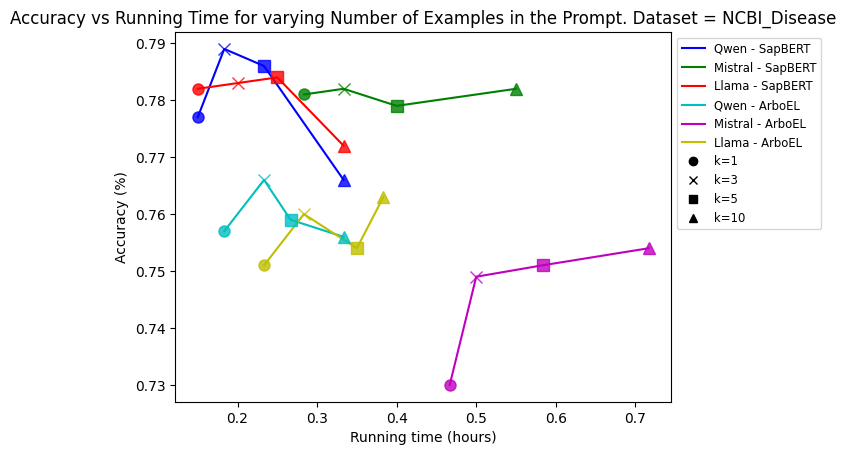

In [3]:
llama_acc_sapbert = [0.782, 0.783, 0.784, 0.772]
llama_time_sapbert = [9/60, 12/60, 15/60, 20/60]

mistral_acc_sapbert = [0.781, 0.782, 0.779, 0.782]
mistral_time_sapbert = [17/60, 20/60, 24/60, 33/60]

qwen_acc_sapbert = [0.777, 0.789, 0.786, 0.766]
qwen_time_sapbert = [9/60, 11/60, 14/60, 20/60]

llama_acc_arboel = [0.751, 0.760, 0.754, 0.763]
llama_time_arboel = [14/60, 17/60, 21/60, 23/60]

mistral_acc_arboel = [0.730, 0.749, 0.751, 0.754]
mistral_time_arboel = [28/60, 30/60, 35/60, 43/60]

qwen_acc_arboel = [0.757, 0.766, 0.759, 0.756]
qwen_time_arboel = [11/60, 14/60, 16/60, 20/60]

# Markers for each point index
markers = ['o', 'x', 's', '^']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['k=1', 'k=3', 'k=5', 'k=10']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = NCBI_Disease')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of candidates in the prompt NCBI_Disease

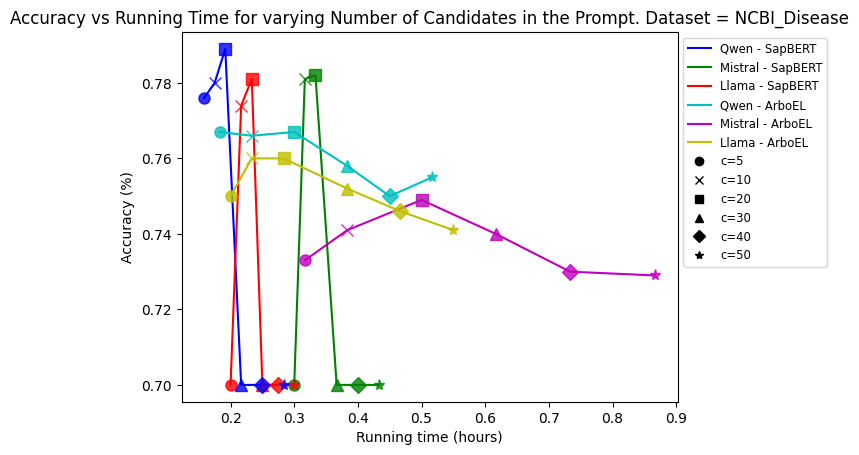

In [34]:
llama_acc_sapbert = [0.7, 0.774, 0.781, 0.7, 0.7, 0.7]
llama_time_sapbert = [12/60, 13/60, 14/60, 15/60, 16.5/60, 18/60]

mistral_acc_sapbert = [0.7, 0.781, 0.782, 0.7, 0.7, 0.7]
mistral_time_sapbert = [18/60, 19/60, 20/60, 22/60, 24/60, 26/60]

qwen_acc_sapbert = [0.776, 0.780, 0.789, 0.7, 0.7, 0.7]
qwen_time_sapbert = [9.5/60, 10.5/60, 11.5/60, 13/60, 15/60, 17/60]

llama_acc_arboel = [0.750, 0.760, 0.760, 0.752, 0.746, 0.741]
llama_time_arboel = [12/60, 14/60, 17/60, 23/60, 28/60, 33/60]

mistral_acc_arboel = [0.733, 0.741, 0.749, 0.740, 0.730, 0.729]
mistral_time_arboel = [19/60, 23/60, 30/60, 37/60, 44/60, 52/60]

qwen_acc_arboel = [0.767, 0.766, 0.767, 0.758, 0.750, 0.755]
qwen_time_arboel = [11/60, 14/60, 18/60, 23/60, 27/60, 31/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D', '*']  # Circle, cross, square, triangle, diamond, star
marker_meanings = ['c=5', 'c=10', 'c=20', 'c=30', 'c=40', 'c=50']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Candidates in the Prompt. Dataset = NCBI_Disease')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of examples in the prompt (GNormPlus)

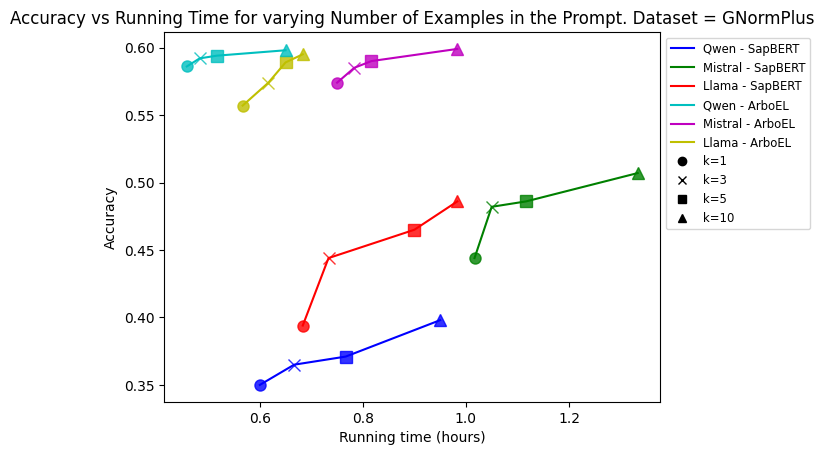

In [113]:
llama_acc_sapbert = [0.394, 0.444, 0.465, 0.486]
llama_time_sapbert = [41/60, 44/60, 54/60, 59/60]

mistral_acc_sapbert = [0.444, 0.482, 0.486, 0.507]
mistral_time_sapbert = [1+1/60, 1+3/60, 1+7/60, 1+20/60]

qwen_acc_sapbert = [0.350, 0.365, 0.371, 0.398]
qwen_time_sapbert = [36/60, 40/60, 46/60, 57/60]

llama_acc_arboel = [0.557, 0.574, 0.589, 0.595]
llama_time_arboel = [34/60, 37/60, 39/60, 41/60]

mistral_acc_arboel = [0.574, 0.585, 0.590, 0.599]
mistral_time_arboel = [45/60, 47/60, 49/60, 59/60]

qwen_acc_arboel = [0.586, 0.592, 0.594, 0.598]
qwen_time_arboel = [27.5/60, 29/60, 31/60, 39/60]

# Markers for each point index
markers = ['o', 'x', 's', '^']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['k=1', 'k=3', 'k=5', 'k=10']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Running Time for varying Number of Examples in the Prompt. Dataset = GNormPlus')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Effect of number of candidates in the prompt (GNormPlus)

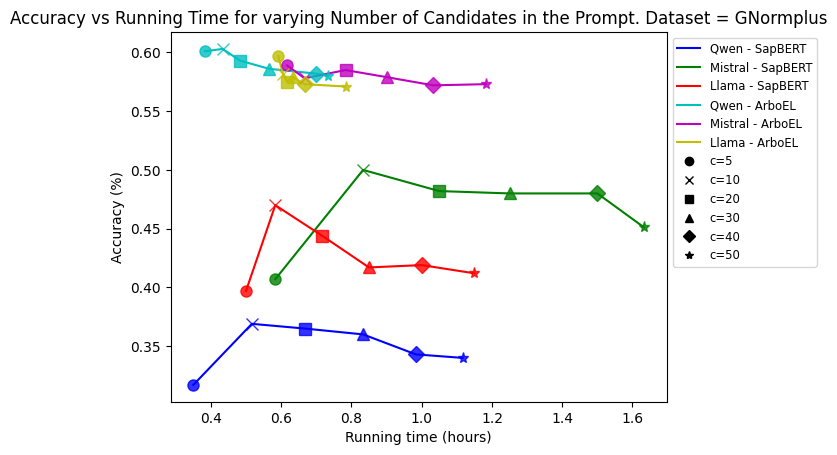

In [35]:
llama_acc_sapbert = [0.397, 0.470, 0.444, 0.417, 0.419, 0.412]
llama_time_sapbert = [30/60, 35/60, 43/60, 51/60, 60/60, 1+9/60]

mistral_acc_sapbert = [0.407, 0.500, 0.482, 0.480, 0.480, 0.451]
mistral_time_sapbert = [35/60, 50/60, 1+3/60, 1+15/60, 1+30/60, 1+38/60]

qwen_acc_sapbert = [0.317, 0.369, 0.365, 0.360, 0.343, 0.340]
qwen_time_sapbert = [21/60, 31/60, 40/60, 50/60, 59/60, 1+7/60]

llama_acc_arboel = [0.597, 0.582, 0.575, 0.579, 0.573, 0.571]
llama_time_arboel = [35.5/60, 36.3/60, 37/60, 38/60, 40/60, 47/60]

mistral_acc_arboel = [0.589, 0.578, 0.585, 0.579, 0.572, 0.573]
mistral_time_arboel = [37/60, 40/60, 47/60, 54/60, 62/60, 71/60]

qwen_acc_arboel = [0.601, 0.603, 0.593, 0.586, 0.582, 0.580]
qwen_time_arboel = [23/60, 26/60, 29/60, 34/60, 42/60, 44/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D', '*']  # Circle, cross, square, triangle, diamond, star
marker_meanings = ['c=5', 'c=10', 'c=20', 'c=30', 'c=40', 'c=50']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
ax.plot(qwen_time_sapbert, qwen_acc_sapbert, color=colors[0], linestyle='-', label='Qwen - SapBERT')
ax.plot(mistral_time_sapbert, mistral_acc_sapbert, color=colors[1], linestyle='-', label='Mistral - SapBERT')
ax.plot(llama_time_sapbert, llama_acc_sapbert, color=colors[2], linestyle='-', label='Llama - SapBERT')

ax.plot(qwen_time_arboel, qwen_acc_arboel, color=colors[3], linestyle='-', label='Qwen - ArboEL')
ax.plot(mistral_time_arboel, mistral_acc_arboel, color=colors[4], linestyle='-', label='Mistral - ArboEL')
ax.plot(llama_time_arboel, llama_acc_arboel, color=colors[5], linestyle='-', label='Llama - ArboEL') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_arboel)):
    ax.plot(qwen_time_sapbert[i], qwen_acc_sapbert[i], marker=markers[i], color=colors[0], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], mistral_acc_sapbert[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], llama_acc_sapbert[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_arboel[i], qwen_acc_arboel[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_arboel[i], mistral_acc_arboel[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_arboel[i], llama_acc_arboel[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Running Time for varying Number of Candidates in the Prompt. Dataset = GNormplus')

# Adding a legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

# Display the plot
plt.show()


## Number of mentions vs running time for the different models

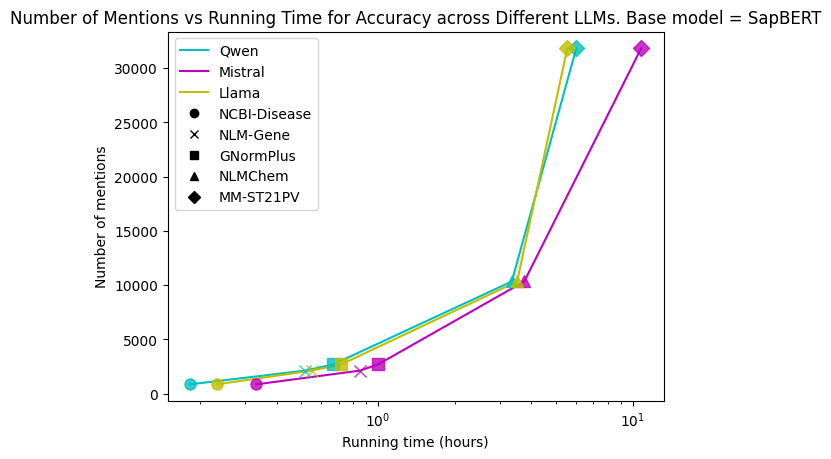

In [39]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

# gpt4o_mini_time_sapbert = [11/60, 38/60, 70/60, 2 + 20/60]

# gpt4o_time_sapbert = [12/60, 28/60, 39/60, 2 + 10/60]

llama_time_sapbert = [14/60, 33/60, 43/60, 3 + 31/60, 5 + 32/60]

mistral_time_sapbert = [20/60, 51/60, 60/60, 3 + 45/60, 10 + 47/60]

qwen_time_sapbert = [11/60, 31/60, 40/60, 3 + 21/60, 6 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(qwen_time_sapbert, X, color=colors[3], linestyle='-', label='Qwen')
ax.plot(mistral_time_sapbert, X, color=colors[4], linestyle='-', label='Mistral')
ax.plot(llama_time_sapbert, X, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_sapbert[i], X[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], X[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], X[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Number of mentions')
ax.set_title('Number of Mentions vs Running Time for Accuracy across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
ax.set_xscale('log')
# ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


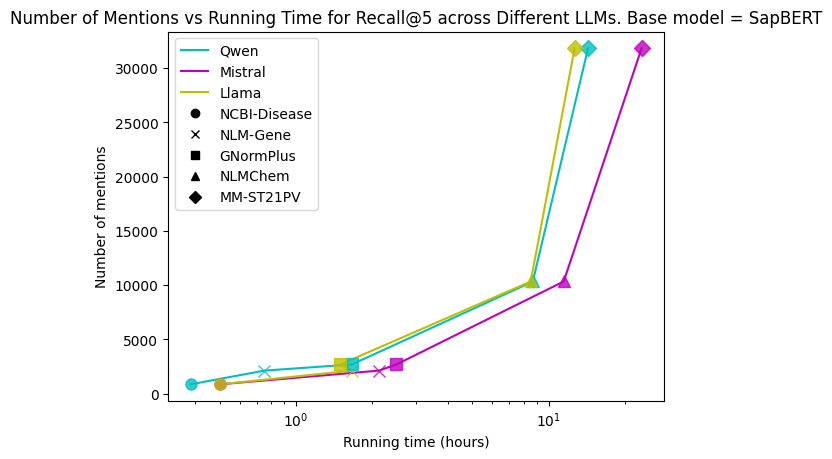

In [40]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

llama_time_sapbert = [30/60, 1 + 40/60, 1 + 30/60, 3 + 5 + 30/60, 12 + 41/60]

mistral_time_sapbert = [30/60, 2 + 8/60, 2 + 30/60, 3 + 8 + 29/60, 23 + 21/60]

qwen_time_sapbert = [23/60, 45/60, 1 + 40/60, 3 + 5 + 40/60, 14 + 20/60]

# gpt4o_mini_time_sapbert = [13/60, 45/60, 1 + 30/60, 4 + 0/60]

# gpt4o_time_sapbert = [16/60, 41/60, 55/60, 4 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(qwen_time_sapbert, X, color=colors[3], linestyle='-', label='Qwen')
ax.plot(mistral_time_sapbert, X, color=colors[4], linestyle='-', label='Mistral')
ax.plot(llama_time_sapbert, X, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(qwen_time_sapbert[i], X[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(mistral_time_sapbert[i], X[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(llama_time_sapbert[i], X[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Running time (hours)')
ax.set_ylabel('Number of mentions')
ax.set_title('Number of Mentions vs Running Time for Recall@5 across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
ax.set_xscale('log')
# ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


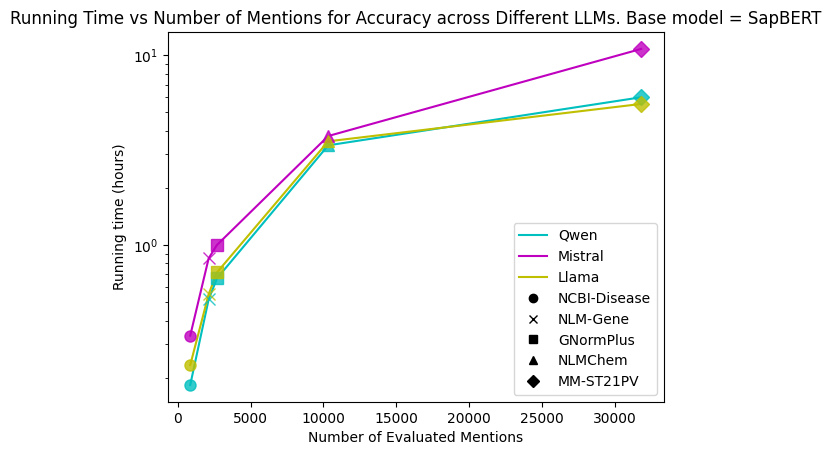

In [43]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

# gpt4o_mini_time_sapbert = [11/60, 38/60, 70/60, 2 + 20/60]

# gpt4o_time_sapbert = [12/60, 28/60, 39/60, 2 + 10/60]

llama_time_sapbert = [14/60, 33/60, 43/60, 3 + 31/60, 5 + 32/60]

mistral_time_sapbert = [20/60, 51/60, 60/60, 3 + 45/60, 10 + 47/60]

qwen_time_sapbert = [11/60, 31/60, 40/60, 3 + 21/60, 6 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(X, qwen_time_sapbert, color=colors[3], linestyle='-', label='Qwen')
ax.plot(X, mistral_time_sapbert, color=colors[4], linestyle='-', label='Mistral')
ax.plot(X, llama_time_sapbert, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], qwen_time_sapbert[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], mistral_time_sapbert[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], llama_time_sapbert[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Number of Evaluated Mentions')
ax.set_ylabel('Running time (hours)')
ax.set_title('Running Time vs Number of Mentions for Accuracy across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
# ax.set_xscale('log')
ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


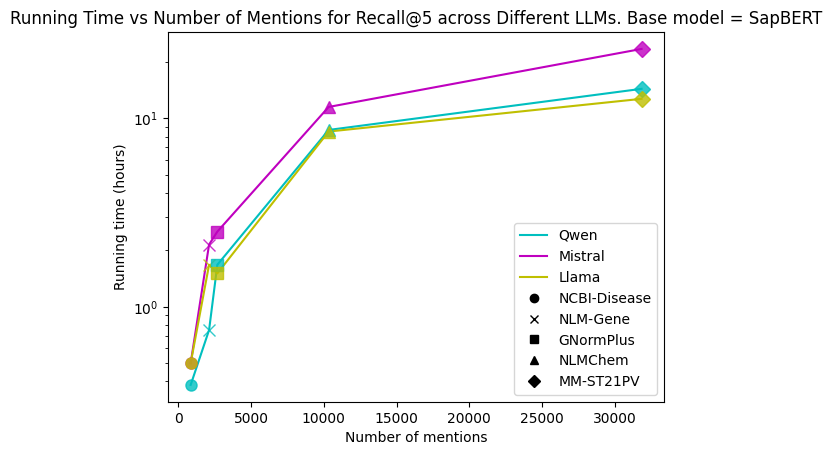

In [42]:
X = [860, 2124, 2692, 10337, 31827] # Dataset size : Number of evaluated mentions

llama_time_sapbert = [30/60, 1 + 40/60, 1 + 30/60, 3 + 5 + 30/60, 12 + 41/60]

mistral_time_sapbert = [30/60, 2 + 8/60, 2 + 30/60, 3 + 8 + 29/60, 23 + 21/60]

qwen_time_sapbert = [23/60, 45/60, 1 + 40/60, 3 + 5 + 40/60, 14 + 20/60]

# gpt4o_mini_time_sapbert = [13/60, 45/60, 1 + 30/60, 4 + 0/60]

# gpt4o_time_sapbert = [16/60, 41/60, 55/60, 4 + 0/60]

# Markers for each point index
markers = ['o', 'x', 's', '^', 'D']  # markers = ['o', 'x', 's', '^', 'D']  # Circle, cross, square, triangle, diamond
marker_meanings = ['NCBI-Disease', 'NLM-Gene', 'GNormPlus', 'NLMChem', 'MM-ST21PV']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']

# Create figure and axes
fig, ax = plt.subplots()

# Plot entire curves to connect the points with lines
# ax.plot(gpt4o_mini_time_sapbert, X[:4], color=colors[1], linestyle='-', label='gpt-4o-mini')
# ax.plot(gpt4o_time_sapbert, X[:4], color=colors[2], linestyle='-', label='gpt-4o')
ax.plot(X, qwen_time_sapbert, color=colors[3], linestyle='-', label='Qwen')
ax.plot(X, mistral_time_sapbert, color=colors[4], linestyle='-', label='Mistral')
ax.plot(X, llama_time_sapbert, color=colors[5], linestyle='-', label='Llama') 

# Plot each point separately with shared markers for the same index across curves
for i in range(len(qwen_time_sapbert)):
    # if i < len(gpt4o_mini_time_sapbert) :
    #     ax.plot(gpt4o_mini_time_sapbert[i], X[i], marker=markers[i], color=colors[1], linestyle='None', alpha=0.8, markersize=8)
    # if i < len(gpt4o_time_sapbert):
    #     ax.plot(gpt4o_time_sapbert[i], X[i], marker=markers[i], color=colors[2], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], qwen_time_sapbert[i], marker=markers[i], color=colors[3], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], mistral_time_sapbert[i], marker=markers[i], color=colors[4], linestyle='None', alpha=0.8, markersize=8)
    ax.plot(X[i], llama_time_sapbert[i], marker=markers[i], color=colors[5], linestyle='None', alpha=0.8, markersize=8)

# Add separate legend entries for each marker type
for i, meaning in enumerate(marker_meanings):
    ax.plot([], [], marker=markers[i], color='black', linestyle='None', label=meaning)

# Adding labels and title
ax.set_xlabel('Number of Evaluated Mentions')
ax.set_ylabel('Running time (hours)')
ax.set_title('Running Time vs Number of Mentions for Recall@5 across Different LLMs. Base model = SapBERT')

# Set logarithmic scale for both x and y axes
# ax.set_xscale('log')
ax.set_yscale('log')

# Adding a legend
ax.legend()

# Display the plot
plt.show()


# Deprecated
# vllm + aqlm 


In [ ]:
llm = LLM(
    model="ISTA-DASLab/Mixtral-8x7B-Instruct-v0_1-AQLM-2Bit-1x16-hf",
    enforce_eager=True,
)

tokenizer = llm.get_tokenizer()

In [30]:
# def prompt_vllm_aqlm(mention, context, system_instructions, candidates, topk_examples, llm, tokenizer, sampling_params):
#     ''' 
#     mention : str (name of the mention to be linked)
#     context : str (context where the mention appears)
#     system_instructions : str (instructions for the LLM)
#     candidates : list of list of CUIs : [[cui1], [cui2, cui3], ...]
#     topk_examples : str (top k examples of similar contexts)
#     llm : LLM model
#     tokenizer : AutoTokenizer
#     sampling_params : SamplingParams config
#     '''
    
#     prompt_text = f"""
#     System Instructions: {system_instructions} \n
    
#     Here are a few examples: \n
#     {topk_examples} \n

#     This is the specific mention that needs to be linked to the correct entity: {mention} \n

#     This is the context where the mention appears: \n
#     {context} \n
    
#     These are the candidate entities to choose from: \n
#     {candidates} \n
    
#     You MUST PROVIDE an ANSWER among the candidates. \n

#     Return the answer in the following format: CUI
#     For instance : "MESH:D000000" "OMIM:000000" are valid answers. \n
#     Do not add provide any explanations ! But you MUST give ONE answer.
#     """
#     conversations = tokenizer.apply_chat_template(
#         [{'role': 'user', 'content': prompt_text}],
#         tokenize=False,
#     )

#     # Decode the generated tokens into text
#     outputs = llm.generate([conversations], sampling_params=sampling_params, use_tqdm=False)
#     answer = outputs[0].outputs[0].text

#     return answer


In [ ]:
mention = "9931324.1"
text = mention2text[mention]
context = mention2context[mention]
candidates = get_candidates_data(mention2biencoder_candidates[mention], ontology2)
topk = topk_examples(model = model,
                    index = index,
                    query=context, 
                    corpus=corpus, 
                    TrainMap_context2mention=TrainMap_context2mention, 
                    train_mention2text=train_mention2text, 
                    train_mention2gold=train_mention2gold, 
                    ontology=ontology2, 
                    k=3)

pred_cui = prompt_vllm_aqlm(mention=text, 
                       context=context, 
                       system_instructions=system_instructions,
                       candidates=candidates, 
                       topk_examples=topk,
                       llm=llm,
                       tokenizer=tokenizer,
                       sampling_params=sampling_params)

# Output the results
print("Mention ID:", mention)
print("Context:", context)
print("Top k examples:", topk)
print("Text:", mention2text[mention])
print("Gold CUI:", mention2gold[mention])
print("Predicted CUI:", pred_cui)

In [44]:
# def evaluate_vllm_aqlm(
#     llm,
#     nlp_model,
#     tokenizer,
#     index,
#     system_instructions,
#     mentions,
#     ontology,
#     corpus,
#     mention2context,
#     mention2biencoder_candidates,
#     mention2text,
#     TrainMap_context2mention,
#     train_mention2text,
#     train_mention2gold,
#     k,
#     sampling_params,
# ):
#     """
#     Run "prompt" function for each mention in the list of mentions.
#     Returns a dictionary {mention_id : predicted CUI}
#     -------
#     llm : LLM model
#     nlp_model : SentenceTransformer model
#     tokenizer : AutoTokenizer
#     index : faiss index
#     system_instructions : str (instructions for the LLM)
#     mentions : list (mention_ids)
#     ontology : BiomedicalOntology object
#     corpus : list of str (all context sentences)
#     mention2context : dict (mention_id : context)
#     mention2biencoder_candidates : dict (mention_id : list of candidate CUIs)
#     mention2text : dict (mention_id : mention name)
#     TrainMap_context2mention : dict (context sentence to mention_id)
#     train_mention2text : dict (mention_id to mention name)
#     train_mention2gold : dict (mention_id to gold CUI)
#     k : int (number of nearest neighbors)
#     sampling_params : SamplingParams config
#     """
#     results = {}
#     for i in range(len(mentions)) :
#         mention_id = mentions[i]
#         mention_name = mention2text[mention_id]
#         context = mention2context[mention_id]
#         candidates = get_candidates_data(mention2biencoder_candidates[mentions[i]], ontology)
#         # candidates = get_candidates_data_v2(mention2arboel_candidates[mention])
#         topk = topk_examples(
#             model=nlp_model,  # sentence transformer model
#             index=index,
#             query=context,
#             corpus=corpus,
#             TrainMap_context2mention=TrainMap_context2mention,
#             train_mention2text=train_mention2text,
#             train_mention2gold=train_mention2gold,
#             ontology=ontology,
#             k=k,
#         )
#         text = prompt_vllm_aqlm(
#             mention=mention_name,
#             context=context,
#             system_instructions=system_instructions,
#             candidates=candidates,
#             topk_examples=topk,
#             llm=llm,
#             tokenizer=tokenizer,
#             sampling_params=sampling_params,
#         )
#         print("mention ID :", mention_id , "|| LLM answer :", text)
#         cand = extract_cui(text)
#         results[mention_id] = cand
#         if i%20 == 0:
#             print(f"i = {i}")

#     return results
    


In [ ]:
results = evaluate_vllm_aqlm(llm=llm,
                        nlp_model=model,
                        tokenizer=tokenizer,
                        index=index,
                        system_instructions=system_instructions,
                        mentions=mentions[:5],
                        ontology=ontology2,
                        corpus=corpus,
                        mention2context=mention2context,
                        mention2biencoder_candidates=mention2biencoder_candidates,
                        mention2text=mention2text,
                        TrainMap_context2mention=TrainMap_context2mention,
                        train_mention2text=train_mention2text,
                        train_mention2gold=train_mention2gold,
                        k=10,
                        sampling_params=sampling_params)
results

In [ ]:
results

In [ ]:
score = scoring(results=results, mention2gold=mention2gold)
score